In [11]:
import zipfile, os

zip_path = "/content/archive (7).zip"
extract_path = "/content/brain_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted folders:", os.listdir(extract_path))


Extracted folders: ['Training', 'Testing']


In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam


In [13]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15

train_dir = extract_path + "/Training"
test_dir  = extract_path + "/Testing"


In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
print("Classes:", train_data.class_indices)


Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.
Classes: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [15]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 48s 453ms/step - accuracy: 0.3774 - loss: 1.3171 - val_accuracy: 0.2513 - val_loss: 1.9767
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 35s 392ms/step - accuracy: 0.4818 - loss: 1.1815 - val_accuracy: 0.3426 - val_loss: 1.8830
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 35s 392ms/step - accuracy: 0.5558 - loss: 1.0135 - val_accuracy: 0.3959 - val_loss: 1.9541
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 35s 392ms/step - accuracy: 0.6182 - loss: 0.9089 - val_accuracy: 0.3985 - val_loss: 2.0358
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 35s 393ms/step - accuracy: 0.6401 - loss: 0.8636 - val_accuracy: 0.4188 - val_loss: 2.3436
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 35s 394ms/step - accuracy: 0.6703 - loss: 0.8105 - val_accuracy: 0.4239 - val_loss: 2.2266
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 35s 390ms/step - accuracy: 0.6619 - loss: 0.8052 - val_accuracy: 0.4137 - val_loss: 2.1048
Epoch 8/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 35s 390ms/step - accuracy: 0.6753 - loss: 0.7721 - val_accu

In [17]:
loss, acc = model.evaluate(test_data)
print(f"Test Accuracy: {acc * 100:.2f}%")


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.2573 - loss: 4.5355
Test Accuracy: 44.67%


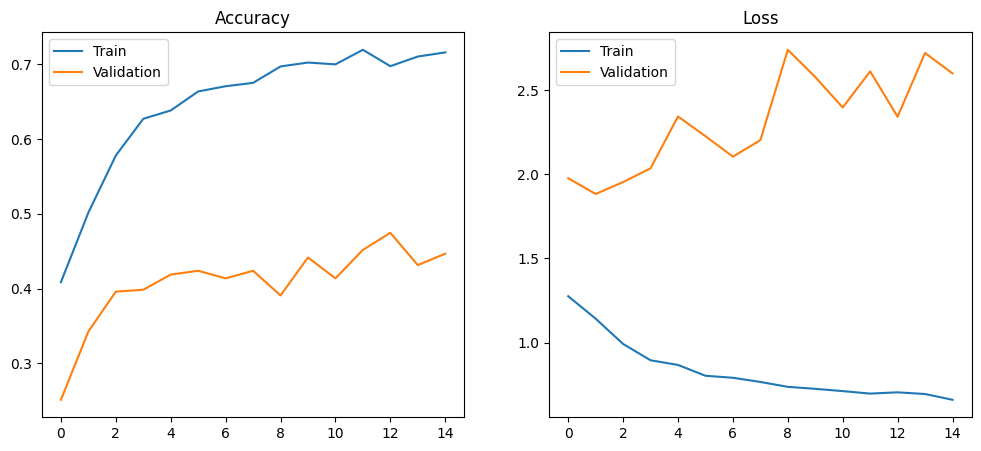

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()


In [19]:
from google.colab import files
uploaded = files.upload()   # upload ONE MRI image (jpg/png)


Saving images (1).jpg to images (1).jpg


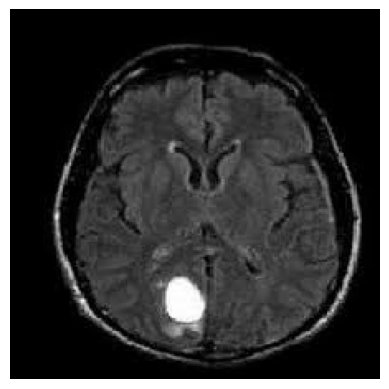

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [20]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Get uploaded image path
img_path = list(uploaded.keys())[0]

# Display image
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
plt.imshow(img)
plt.axis('off')
plt.show()

# Preprocess image
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)
predicted_index = np.argmax(prediction)

class_labels = list(train_data.class_indices.keys())
predicted_label = class_labels[predicted_index]
confidence = np.max(prediction) * 100


In [23]:

print(f"Confidence: {confidence:.2f}%")

if predicted_label.lower() == "notumor":
    print("✅ RESULT: NO BRAIN TUMOR DETECTED")
else:
    print("⚠️ RESULT: BRAIN TUMOR DETECTED")


Confidence: 89.86%
⚠️ RESULT: BRAIN TUMOR DETECTED


In [25]:
!pip install gradio


In [26]:
import gradio as gr
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image


In [29]:
class_labels = ["glioma", "meningioma", "no_tumor", "pituitary"]
IMG_SIZE = 224


In [30]:
def predict_brain_tumor(img):
    # Resize & preprocess
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    preds = model.predict(img_array)
    idx = np.argmax(preds)
    confidence = np.max(preds) * 100
    label = class_labels[idx]

    # Tumor / No tumor decision
    if label.lower() in ["no_tumor", "notumor"]:
        result = "✅ NO BRAIN TUMOR DETECTED"
    else:
        result = "⚠️ BRAIN TUMOR DETECTED"

    return (
        f"Predicted Class: {label}\n"
        f"Confidence: {confidence:.2f}%\n\n"
        f"{result}"
    )


In [31]:
interface = gr.Interface(
    fn=predict_brain_tumor,
    inputs=gr.Image(type="pil", label="Upload Brain MRI Image"),
    outputs=gr.Textbox(label="Prediction Result"),
    title="🧠 Brain Tumor Detection Dashboard",
    description=(
        "Upload a brain MRI image to classify whether a tumor is present.\n\n"
        "⚠️ This tool is for educational purposes only and not for medical diagnosis."
    ),
    examples=None
)


In [ ]:
interface.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8c31d8911de6927944.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1138, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
